# Training in practice

Everything so far has been about what a network *can* represent. This notebook
is about the gap between that and what you actually get, which is where the
whole practice of training networks lives.

Four questions, in the order they bite:

1. What learning rate? — the one setting that can take a working network to
   chance.
2. Which optimiser? — notebook 01 left a network stuck below its own
   architecture's reach, and this is the repair.
3. The network fits the training set perfectly. Is that a problem?
4. Given that it is, what actually helps — and how would you know, on a
   validation set of 360 examples?

Handout sections 9 and 10.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 tensorflow-cpu==2.21.0

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from instrument_data import (make_acceptance_test, load_digit_images,
                             TRUE_N_CLASSES, TRUE_RIG_ERROR_RATE)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"
tf.config.experimental.enable_op_determinism()

X_tr, y_tr, X_va, y_va, X_te, y_te = load_digit_images()
print(f"digits: train {X_tr.shape}, validation {X_va.shape}, test {X_te.shape}")
print(f"one validation example is worth {100 / len(X_va):.3f} percentage points")
print(f"binomial standard error near 95% on {len(X_va)} points: "
      f"{np.sqrt(.95 * .05 / len(X_va)) * 100:.2f} points")

I0000 00:00:1787307996.454183 2091081 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787307997.681535 2091081 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


digits: train (1077, 64), validation (360, 64), test (360, 64)
one validation example is worth 0.278 percentage points
binomial standard error near 95% on 360 points: 1.15 points


Read that last line before any of the numbers below. On 360 validation
examples, two methods differing by one percentage point are **not**
distinguishable — that difference is about one standard error. This notebook
reports spreads across seeds throughout for exactly that reason, and there is
one comparison below where the honest answer turns out to be "cannot tell".

## 2. The learning rate

Lesson 3 introduced $\alpha$ and showed a cost curve diverging when it was too
large. In a network the same failure is available, plus a subtler one: a rate
small enough to be stable can be far too small to arrive.

In [2]:
def digit_model(hidden=(64, 64), seed=0, optimizer=None, dropout=0.0,
                l2=0.0, activation="relu"):
    keras.utils.set_random_seed(seed)
    regulariser = keras.regularizers.l2(l2) if l2 else None
    model = keras.Sequential([keras.Input(shape=(64,))])
    for width in hidden:
        model.add(layers.Dense(width, activation=activation,
                               kernel_regularizer=regulariser))
        if dropout:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(TRUE_N_CLASSES, activation="softmax",
                           kernel_regularizer=regulariser))
    model.compile(optimizer=optimizer or keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


rates = (0.001, 0.01, 0.1, 0.5, 2.0)
rate_rows, rate_curves = [], {}
for rate in rates:
    finals, losses = [], []
    for seed in range(3):
        model = digit_model(seed=seed, optimizer=keras.optimizers.SGD(rate))
        history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                            epochs=60, batch_size=32, verbose=0).history
        finals.append(history["val_accuracy"][-1])
        losses.append(history["loss"][-1])
        if seed == 0:
            rate_curves[rate] = history["loss"]
    rate_rows.append({"learning rate": rate,
                      "final training loss": np.mean(losses),
                      "validation accuracy": np.mean(finals),
                      "sd": np.std(finals)})
pd.DataFrame(rate_rows).set_index("learning rate").round(4)

,final training loss,validation accuracy,sd
learning rate,,,
0.001,1.9550,0.5574,0.0794
0.010,0.1965,0.9398,0.0035
0.100,0.0115,0.9556,0.0039
0.500,0.0007,0.9685,0.0026
2.000,2.3222,0.1009,0.0013


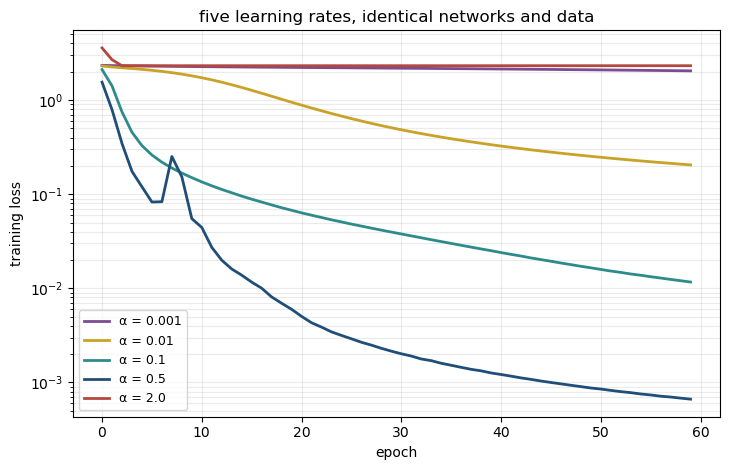

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for rate, colour in zip(rates, (PLUM, GOLD, TEAL, BLUE, RUST)):
    ax.plot(rate_curves[rate], color=colour, lw=2.0, label=f"α = {rate}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("five learning rates, identical networks and data")
ax.legend(fontsize=9)
ax.grid(alpha=.25, which="both")
fig.tight_layout()
fig.savefig(FIGURES / "learning_rate_sweep.png", dpi=150)
plt.show()

Three regimes, and the useful range between them is narrow. Too small and the
loss is still falling when the epochs run out — the network is not broken, it
is unfinished, and it looks exactly like a network that lacks capacity. Too
large and the loss goes nowhere at all: the steps overshoot every minimum they
approach, and accuracy sits at chance for ten classes.

**The predictable mistake here is diagnosing the first case as the second
problem.** A network that underfits because $\alpha$ is too small looks like a
network that is too small, and the reasonable response — add units, add
layers — makes it slower without making it better. Always vary the learning
rate over orders of magnitude before touching the architecture.

## 3. What a large learning rate does to ReLU units

A ReLU unit whose pre-activation is negative for every training example
outputs zero for all of them, and therefore receives zero gradient for all of
them — for ever. It is **dead**: it will never contribute again, and no amount
of further training will revive it. Large steps are what kill them, by
knocking the bias far enough negative in a single update.

In [4]:
dead_rows = []
for rate in (0.001, 0.01, 0.1, 0.5, 1.0):
    keras.utils.set_random_seed(0)
    model = keras.Sequential([keras.Input(shape=(64,)),
                              layers.Dense(64, activation="relu", name="hidden"),
                              layers.Dense(TRUE_N_CLASSES, activation="softmax")])
    model.compile(optimizer=keras.optimizers.SGD(rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.fit(X_tr, y_tr, epochs=40, batch_size=32, verbose=0)
    probe = keras.Model(model.inputs, model.get_layer("hidden").output)
    activations = probe.predict(X_tr, verbose=0)
    dead_rows.append({"learning rate": rate,
                      "dead units (of 64)": int((activations.max(axis=0) == 0).sum()),
                      "training accuracy": model.evaluate(X_tr, y_tr, verbose=0)[1],
                      "validation accuracy": model.evaluate(X_va, y_va, verbose=0)[1]})
dead = pd.DataFrame(dead_rows).set_index("learning rate")
dead.round(4)

,dead units (of 64),training accuracy,validation accuracy
learning rate,,,
0.001,3,0.4410,0.4472
0.010,3,0.9164,0.9250
0.100,5,0.9879,0.9611
0.500,4,1.0000,0.9667
1.000,33,1.0000,0.9583


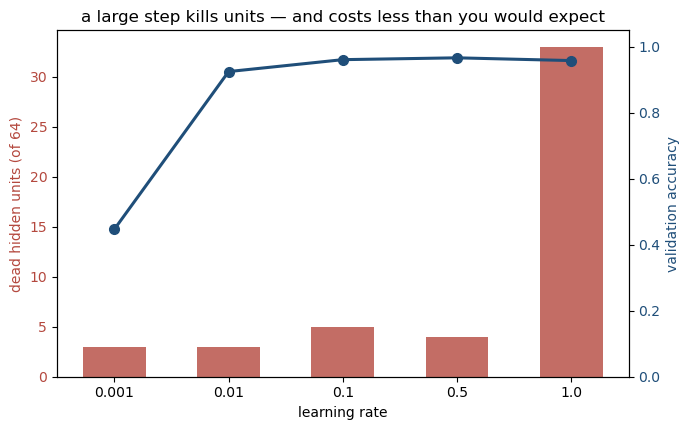

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
positions = np.arange(len(dead))
ax.bar(positions, dead["dead units (of 64)"], color=RUST, alpha=.8, width=.55)
ax.set_xticks(positions)
ax.set_xticklabels(dead.index)
ax.set_xlabel("learning rate")
ax.set_ylabel("dead hidden units (of 64)", color=RUST)
ax.tick_params(axis="y", labelcolor=RUST)

twin = ax.twinx()
twin.plot(positions, dead["validation accuracy"], "o-", color=BLUE, lw=2.2, ms=7)
twin.set_ylabel("validation accuracy", color=BLUE)
twin.tick_params(axis="y", labelcolor=BLUE)
twin.set_ylim(0, 1.05)
ax.set_title("a large step kills units — and costs less than you would expect")
fig.tight_layout()
fig.savefig(FIGURES / "dead_relu.png", dpi=150)
plt.show()

The interesting part is the second half of the title. At the largest rate a
substantial fraction of the layer is dead, and validation accuracy is barely
below its best. The survivors absorb the work.

So dead units are usually **wasted capacity rather than a catastrophe**, which
is why the failure is easy to miss: nothing in the training curve announces
it. Worth knowing anyway, because a layer of 64 that is half dead is a layer
of 31, and if that layer were the bottleneck you would be tuning everything
except the thing that is actually wrong.

## 4. Optimisers, and the promise notebook 01 left open

Notebook 01's width sweep flattened at about 0.947 while the best fence of the
same number of lines kept climbing to 0.969. The lines were available and
plain gradient descent did not use them. That is an optimiser problem, so here
is the same architecture — 16 hidden units on the acceptance data — under
three optimisers.

Momentum accumulates a running average of past gradients, so it keeps moving
along directions that have been consistently downhill and cancels the
oscillation across a narrow valley. Adam adds a per-parameter step size,
scaling each coordinate by a running estimate of its own gradient magnitude,
which is what makes it forgiving of a badly chosen global rate.

In [6]:
units = make_acceptance_test()
Xa = units[["gain_offset_db", "phase_offset_deg"]].values
ya = units["accepted"].values
ta = units["truly_within_tolerance"].values
Xa_tr, Xa_te, ya_tr, ya_te, ta_tr, ta_te = train_test_split(
    Xa, ya, ta, test_size=0.25, stratify=ya, random_state=9101)
scaler = StandardScaler().fit(Xa_tr)
Za_tr, Za_te = scaler.transform(Xa_tr), scaler.transform(Xa_te)


def acceptance_model(seed, optimizer):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(16, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model


optimisers = {
    "plain gradient descent": lambda: keras.optimizers.SGD(0.3),
    "with momentum 0.9": lambda: keras.optimizers.SGD(0.3, momentum=0.9),
    "Adam": lambda: keras.optimizers.Adam(0.01),
}

optimiser_rows, optimiser_curves = [], {}
for name, make in optimisers.items():
    scores, truth_scores = [], []
    for seed in range(5):
        model = acceptance_model(seed, make())
        history = model.fit(Za_tr, ya_tr, epochs=200, batch_size=64,
                            verbose=0).history
        scores.append(model.evaluate(Za_te, ya_te, verbose=0)[1])
        truth_scores.append(model.evaluate(Za_te, ta_te, verbose=0)[1])
        if seed == 0:
            optimiser_curves[name] = history["loss"]
    optimiser_rows.append({"optimiser": name,
                           "test accuracy": np.mean(scores),
                           "sd": np.std(scores),
                           "worst of 5": min(scores),
                           "vs the true rule": np.mean(truth_scores)})
print(f"the ceiling is {1 - TRUE_RIG_ERROR_RATE:.2f}; "
      f"notebook 01 reached 0.9475 here, using five restarts\n")
pd.DataFrame(optimiser_rows).set_index("optimiser").round(4)

the ceiling is 0.97; notebook 01 reached 0.9475 here, using five restarts



,test accuracy,sd,worst of 5,vs the true rule
optimiser,,,,
plain gradient descent,0.9389,0.0184,0.9027,0.9685
with momentum 0.9,0.9349,0.0094,0.9173,0.9645
Adam,0.9485,0.0072,0.9360,0.9792


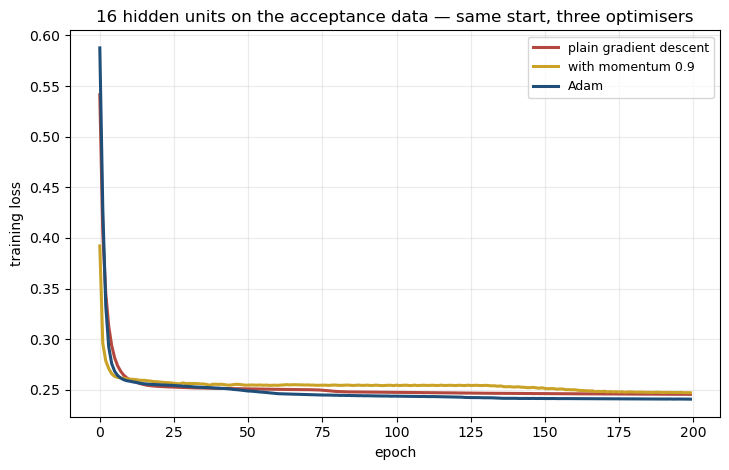

In [7]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for (name, curve), colour in zip(optimiser_curves.items(), (RUST, GOLD, BLUE)):
    ax.plot(curve, color=colour, lw=2.2, label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("16 hidden units on the acceptance data — same start, three optimisers")
ax.legend(fontsize=9)
ax.grid(alpha=.25)
fig.tight_layout()
fig.savefig(FIGURES / "optimiser_comparison.png", dpi=150)
plt.show()

Read the `sd` and `worst of 5` columns before the mean, because that is where
the difference actually is.

**Adam's mean is about one point above plain gradient descent, and its worst
run is more than three points above.** The spread more than halves. What Adam
mainly bought here was not a better best case but the disappearance of the bad
case — and a bad case is precisely what notebook 01 had to spend five restarts
insuring against. Adam in a single run matches what plain descent reached with
five, which is the promise that notebook left open.

**Momentum, on this problem, did nothing.** Its mean is a fraction of a point
*below* plain gradient descent, well inside the seed-to-seed spread of either.
That is worth stating plainly rather than quietly omitting: momentum is a good
default and it is not a guarantee, and a table of three methods where one of
them fails to help is a more honest picture of tuning than a table where every
row improves on the last.

The last column is the reminder from notebook 01. Every one of these
optimisers agrees with the *true* acceptance rule several points more often
than its measured accuracy suggests, because 3% of the recorded verdicts are
wrong.

## 5. A network that fits its training set perfectly

Now the other failure. Two hidden layers of 512 on a deliberately small
training set — 300 digits, which is what a real problem often gives you.

In [8]:
X_small, _, y_small, _ = train_test_split(X_tr, y_tr, train_size=300,
                                          stratify=y_tr, random_state=9004)
big = digit_model(hidden=(512, 512), seed=0)
print(f"{big.count_params():,} parameters, {len(X_small)} training examples")
print(f"that is {big.count_params() / len(X_small):,.0f} parameters per example")

big_history = big.fit(X_small, y_small, validation_data=(X_va, y_va),
                      epochs=200, batch_size=32, verbose=0).history
print(f"\nfinal training accuracy  : {big_history['accuracy'][-1]:.4f}")
print(f"final validation accuracy: {big_history['val_accuracy'][-1]:.4f}")
print(f"best validation accuracy : {max(big_history['val_accuracy']):.4f}"
      f"  at epoch {int(np.argmax(big_history['val_accuracy'])) + 1}")

301,066 parameters, 300 training examples
that is 1,004 parameters per example

final training accuracy  : 1.0000
final validation accuracy: 0.9472
best validation accuracy : 0.9500  at epoch 17


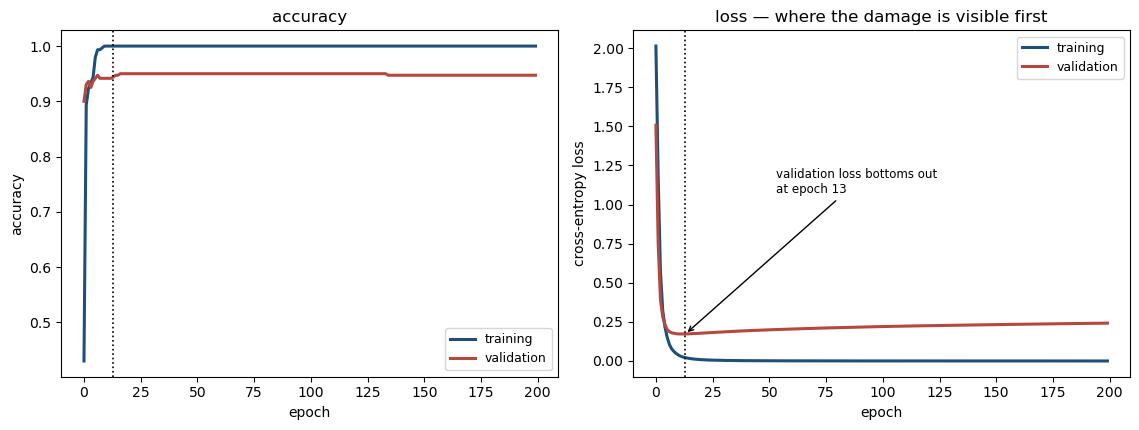

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
axes[0].plot(big_history["accuracy"], color=BLUE, lw=2.2, label="training")
axes[0].plot(big_history["val_accuracy"], color=RUST, lw=2.2, label="validation")
axes[0].set_ylabel("accuracy")
axes[0].set_title("accuracy")
axes[1].plot(big_history["loss"], color=BLUE, lw=2.2, label="training")
axes[1].plot(big_history["val_loss"], color=RUST, lw=2.2, label="validation")
axes[1].set_ylabel("cross-entropy loss")
axes[1].set_title("loss — where the damage is visible first")
best_epoch = int(np.argmin(big_history["val_loss"])) + 1
for ax in axes:
    ax.axvline(best_epoch, color="k", lw=1.2, ls=":")
    ax.set_xlabel("epoch")
    ax.legend(fontsize=9)
axes[1].annotate(f"validation loss bottoms out\nat epoch {best_epoch}",
                 xy=(best_epoch, min(big_history["val_loss"])),
                 xytext=(best_epoch + 40, min(big_history["val_loss"]) + 0.9),
                 fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=1.0))
fig.tight_layout()
fig.savefig(FIGURES / "overfitting_curves.png", dpi=150)
plt.show()

Two things are worth separating here, because they are usually run together
and only one of them is a problem.

**The network memorises the training set.** Training accuracy reaches 1.000
and the training loss goes to essentially zero: with a thousand parameters per
example there is more than enough freedom to store the answers outright.

**And it generalises anyway.** Validation accuracy is far above chance and
stays there. This is the fact that classical bias–variance intuition from
lesson 5 does not lead you to expect, and it is genuinely how large networks
behave.

What *does* degrade is the validation **loss**, which bottoms out early and
then climbs for the rest of training while validation accuracy holds roughly
flat. The network is not getting more answers wrong; it is getting steadily
more confident about the ones it already has wrong. Accuracy cannot see that
and cross-entropy can, which is the argument for watching the loss.

## 6. Three ways to intervene, measured honestly

Early stopping, dropout, L2 — all standard, all recommended everywhere. The
question this section actually answers is not "do they help" but "on this
problem, with this validation set, **can we tell**?"

The protocol is lesson 5's. Each configuration is trained with early stopping
on the validation set, the best weights are restored, and the score reported
is on the **test set**, which nothing has been chosen against. Five seeds each.

In [10]:
def evaluate(name, seeds=5, **kwargs):
    tests, gaps, stopped = [], [], []
    for seed in range(seeds):
        model = digit_model(hidden=(512, 512), seed=seed, **kwargs)
        stopper = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=25, restore_best_weights=True)
        history = model.fit(X_small, y_small, validation_data=(X_va, y_va),
                            epochs=250, batch_size=32, verbose=0,
                            callbacks=[stopper]).history
        tests.append(model.evaluate(X_te, y_te, verbose=0)[1])
        gaps.append(model.evaluate(X_small, y_small, verbose=0)[1] - tests[-1])
        stopped.append(len(history["loss"]))
    return {"method": name, "test accuracy": np.mean(tests),
            "sd": np.std(tests), "train − test gap": np.mean(gaps),
            "epochs run": np.mean(stopped)}


results = pd.DataFrame([
    evaluate("early stopping only"),
    evaluate("+ dropout 0.4", dropout=0.4),
    evaluate("+ L2 1e-3", l2=1e-3),
    evaluate("+ dropout 0.4 and L2 1e-3", dropout=0.4, l2=1e-3),
]).set_index("method")
results.round(4)

,test accuracy,sd,train − test gap,epochs run
method,,,,
early stopping only,0.9411,0.0069,0.0589,38.8
+ dropout 0.4,0.9483,0.0038,0.0503,48.8
+ L2 1e-3,0.9478,0.0011,0.0522,198.4
+ dropout 0.4 and L2 1e-3,0.9511,0.0045,0.0489,161.6


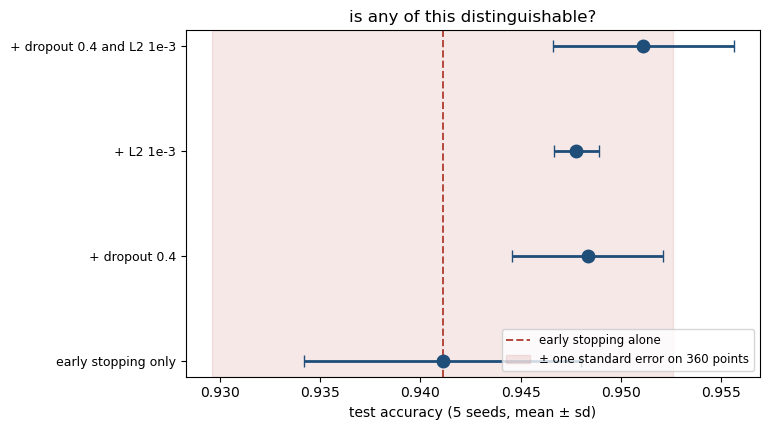

In [11]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
positions = np.arange(len(results))
ax.errorbar(results["test accuracy"], positions, xerr=results["sd"], fmt="o",
            color=BLUE, ms=9, capsize=4, lw=2)
baseline = results["test accuracy"].iloc[0]
ax.axvline(baseline, color=RUST, lw=1.4, ls="--", label="early stopping alone")
ax.axvspan(baseline - np.sqrt(.95 * .05 / len(y_te)),
           baseline + np.sqrt(.95 * .05 / len(y_te)),
           color=RUST, alpha=.12, label="± one standard error on 360 points")
ax.set_yticks(positions)
ax.set_yticklabels(results.index, fontsize=9)
ax.set_xlabel("test accuracy (5 seeds, mean ± sd)")
ax.set_title("is any of this distinguishable?")
ax.legend(fontsize=8.5, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "regularisation_comparison.png", dpi=150)
plt.show()

All three interventions land between 0.7 and 1.0 points above early stopping
alone. Whether that is a result depends entirely on what you compare it to,
and there are two different spreads in play — which is exactly the confusion
this section exists to force into the open.

The **seed-to-seed spread** is 0.1 to 0.7 points: retrain the same
configuration and this is how much the answer moves. Against that, gains of
0.7 to 1.0 points are one to two standard deviations — suggestive, and no
more. On a single run with one seed you could comfortably have measured the
three methods in any order.

The **test set** is 360 examples, so one point is roughly four examples
changing hands. The four rows are all scored on the *same* 360 examples, so
they are not independent measurements and the comparison is better than a
naive standard error suggests — but not by enough to turn a one-point gap into
a finding.

The honest summary: **dropout and L2 help here, slightly, and this experiment
cannot rank them.** Note also the `epochs run` column — L2 kept the validation
loss improving for roughly four times as long before early stopping fired,
which is a real qualitative difference even where the final scores are not
separable.

Reporting it this way is not excessive caution. A table of four numbers with
no spread beside them would have supported a confident sentence about which
regulariser is best, and that sentence would have been unfounded.

## 7. The intervention that is not a hyperparameter

Everything in section 6 tries to make better use of 300 examples. This is what
having more of them is worth, holding the architecture and the protocol fixed.

In [12]:
size_rows = []
for size in (100, 200, 300, 500, 800, len(X_tr)):
    subset_x, subset_y = (X_tr, y_tr) if size == len(X_tr) else train_test_split(
        X_tr, y_tr, train_size=size, stratify=y_tr, random_state=9004)[::2]
    scores = []
    for seed in range(3):
        model = digit_model(hidden=(512, 512), seed=seed)
        stopper = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=25, restore_best_weights=True)
        model.fit(subset_x, subset_y, validation_data=(X_va, y_va), epochs=250,
                  batch_size=32, verbose=0, callbacks=[stopper])
        scores.append(model.evaluate(X_te, y_te, verbose=0)[1])
    size_rows.append({"training examples": len(subset_x),
                      "test accuracy": np.mean(scores), "sd": np.std(scores)})
sizes = pd.DataFrame(size_rows).set_index("training examples")
sizes.round(4)

,test accuracy,sd
training examples,,
100,0.9028,0.0060
200,0.9426,0.0047
300,0.9463,0.0035
500,0.9694,0.0039
800,0.9722,0.0000
1077,0.9787,0.0026


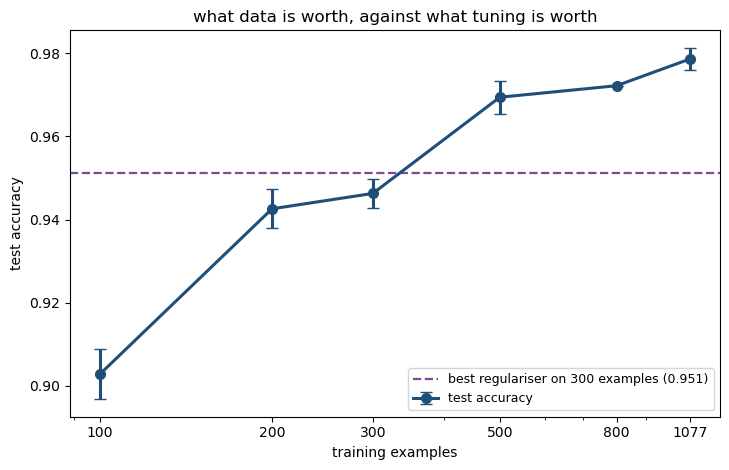

300 -> 1077 examples is worth +3.2 points
the best regulariser at 300 examples was worth +1.0 points


In [13]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.errorbar(sizes.index, sizes["test accuracy"], yerr=sizes["sd"], fmt="o-",
            color=BLUE, lw=2.2, ms=7, capsize=4, label="test accuracy")
best_regularised = results["test accuracy"].max()
ax.axhline(best_regularised, color=PLUM, lw=1.6, ls="--",
           label=f"best regulariser on 300 examples ({best_regularised:.3f})")
ax.set_xscale("log")
ax.set_xticks(sizes.index)
ax.set_xticklabels(sizes.index)
ax.set_xlabel("training examples")
ax.set_ylabel("test accuracy")
ax.set_title("what data is worth, against what tuning is worth")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "training_size_curve.png", dpi=150)
plt.show()

step = sizes["test accuracy"].iloc[-1] - sizes["test accuracy"].loc[300]
print(f"300 -> {sizes.index[-1]} examples is worth {step * 100:+.1f} points")
print(f"the best regulariser at 300 examples was worth "
      f"{(best_regularised - results['test accuracy'].iloc[0]) * 100:+.1f} points")

## Summary

- **The learning rate is the first thing to sweep and the last thing to
  guess.** Across three orders of magnitude it takes this network from
  unfinished, through working, to chance. A network starved of learning rate
  looks exactly like a network starved of capacity, and the natural repair
  makes it worse.
- A large rate kills ReLU units outright. The survivors cover for them, so the
  cost is quiet: wasted capacity rather than visible failure.
- Adam earns its default status by shrinking the **worst** case, not the best:
  same mean to within a point, less than half the spread, and in one run what
  plain gradient descent needed five restarts to reach. Momentum, on the same
  problem, did not help at all.
- An over-parameterised network memorises its training set completely and
  still generalises. Watch the validation **loss**, not accuracy: the loss
  turns upward long before accuracy does, because the network is growing
  confident about its mistakes.
- Report a difference with the spread it was measured against. Dropout and L2
  each bought under a point on a 360-example test set, against a seed-to-seed
  spread of up to 0.7 — enough to say they helped, nowhere near enough to rank
  them.
- More data outperformed every regulariser tried here by a factor of three,
  and unlike them it is not a hyperparameter you can tune your way to.

Lesson 10 keeps the architecture and changes the assumption: that a pixel's
neighbours matter more than a pixel's index.